# 1. Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


# 2. Load Dataset

In [3]:
df = pd.read_csv("../Data/Responses.csv")

# Preview
df.head()


,Timestamp,Age,Gender,How many hours do you use Wi-Fi daily?,YouTube usage (hours/day),Instagram usage (hours/day),"OTT usage (Netflix, Prime, etc.) (hours/day)",Educational usage (lectures/study) (hours/day),How many hours do you study daily?,Rate your daily productivity level (1–10) based on your academic tasks,Do you use your phone while studying?,Do you feel distracted due to internet usage?,How many hours do you sleep daily?,What distracts you the most while using Wi-Fi?
0,4/1/2026 21:59:56,19,Female,10,2.0,1,Movierulz,6,6,7,No,Rarely,7,Notifications from social media apps
1,4/1/2026 22:00:01,19,Female,24,1.0,5,5,5,5,10,Yes,Often,8hrs,Generally wifi is the one which is most distra...
2,4/1/2026 22:02:11,19,Female,20,8.0,8,2,6,7,4,Yes,Sometimes,10,Notifications from the shopping apps
3,4/1/2026 22:10:17,19,Female,10,0.5,4,0.5,3,2,3,No,Often,Minimum 6,Instagram and notifications from friends and g...
4,4/1/2026 22:12:37,20,Female,8,1.0,3,0,1,1,2,Yes,Often,6,Instagram clash royale and whatsapp


# 3. Data Cleaning

# 3.1 Clean Column Names

In [4]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")


# 3.2 Rename Important Columns

In [5]:
df.rename(columns={
    "How_many_hours_do_you_use_Wi-Fi_daily?": "wifi_hours",
    "YouTube_usage_(hours/day)": "youtube",
    "Instagram_usage_(hours/day)": "instagram",
    "OTT_usage_(Netflix,_Prime,_etc.)_(hours/day)": "ott",
    "Educational_usage_(lectures/study)_(hours/day)": "edu",
    "How_many_hours_do_you_study_daily?": "study",
    "Rate_your_daily_productivity_level_(1–10)_based_on_your_academic_tasks": "productivity",
    "How_many_hours_do_you_sleep_daily?": "sleep"
}, inplace=True)


# 3.3 Convert Text → Numeric

In [6]:
def clean_hours(x):
    if pd.isna(x):
        return np.nan

    x = str(x).lower()

    # remove text
    x = re.sub(r'[^0-9\.\-]', '', x)

    # handle ranges (5-6 → 5.5)
    if '-' in x:
        parts = x.split('-')
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except:
            return np.nan

    try:
        return float(x)
    except:
        return np.nan


# 3.4 Apply Cleaning

In [7]:
cols = ['wifi_hours','youtube','instagram','ott','edu','study','sleep']

for col in cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_hours)


# 3.5 Clean Productivity

In [8]:
df['productivity'] = pd.to_numeric(df['productivity'], errors='coerce')


# 3.6 Remove Outliers

In [9]:
df = df[df['wifi_hours'] <= 24]
df = df[(df['sleep'] >= 3) & (df['sleep'] <= 12)]
df = df[df['instagram'] <= 24]


# 3.7 Handle Missing Values

In [10]:
df.fillna(df.median(numeric_only=True), inplace=True)


# 3.8 Remove Duplicates

In [11]:
df.drop_duplicates(inplace=True)


# 4. Exploratory Data Analysis

# Summary Statistics

In [12]:
df.describe()


,Age,wifi_hours,youtube,instagram,ott,edu,study,productivity,sleep
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,19.313725,14.470588,2.328745,3.950980,1.480392,2.766667,2.637255,4.941176,7.401961
std,1.714528,6.126509,1.718789,3.494646,1.658194,3.236150,2.854958,2.148597,1.452651
min,18.000000,3.000000,0.100000,0.000000,0.000000,0.000000,0.000000,1.000000,5.000000
25%,19.000000,10.000000,1.000000,2.000000,0.000000,1.000000,1.000000,3.000000,6.000000
50%,19.000000,14.000000,2.000000,3.000000,1.000000,2.000000,2.000000,5.000000,7.000000
75%,19.000000,18.000000,3.000000,5.000000,2.000000,3.500000,3.000000,6.000000,8.000000
max,30.000000,24.000000,8.000000,24.000000,6.000000,20.000000,15.000000,10.000000,12.000000


# Distribution Analysis

# Distribution plots

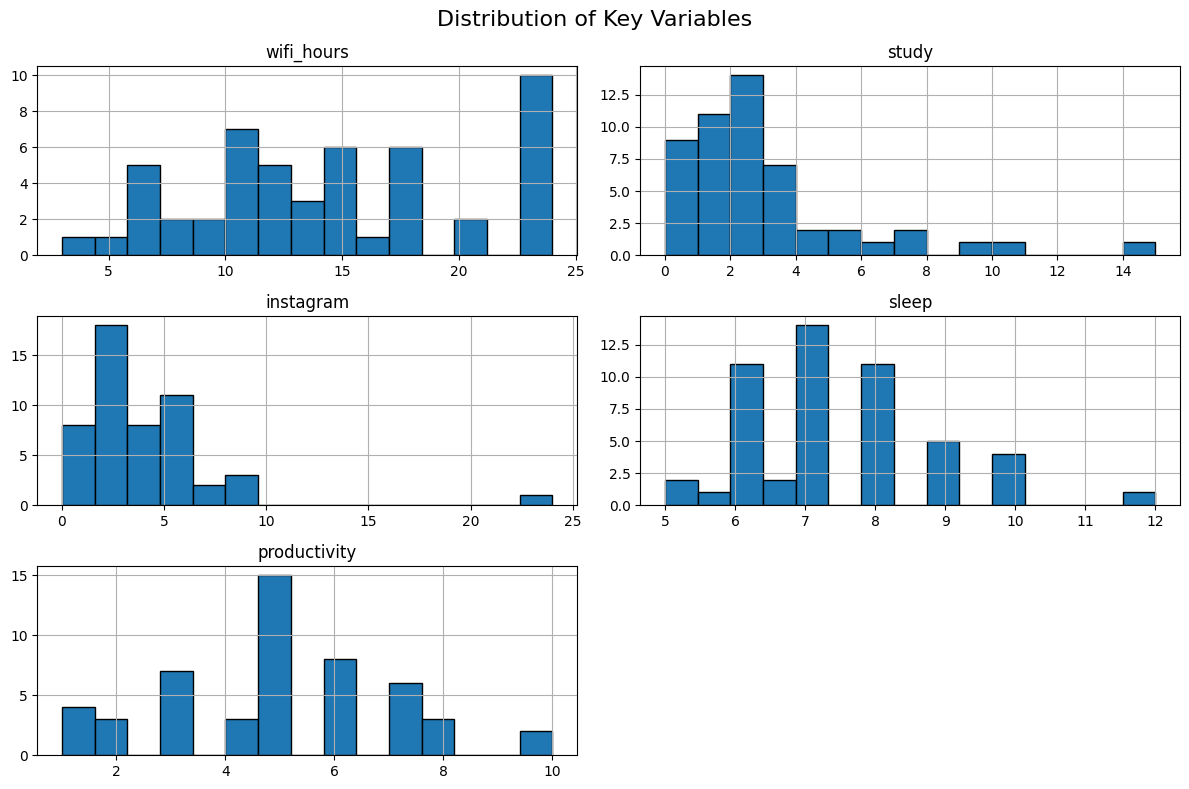

In [13]:
df[['wifi_hours','study','instagram','sleep','productivity']].hist(
    figsize=(12,8),
    bins=15,
    edgecolor='black'
)

plt.suptitle("Distribution of Key Variables", fontsize=16)

plt.tight_layout()
plt.show()


# KDE plots

# Study Hours KDE

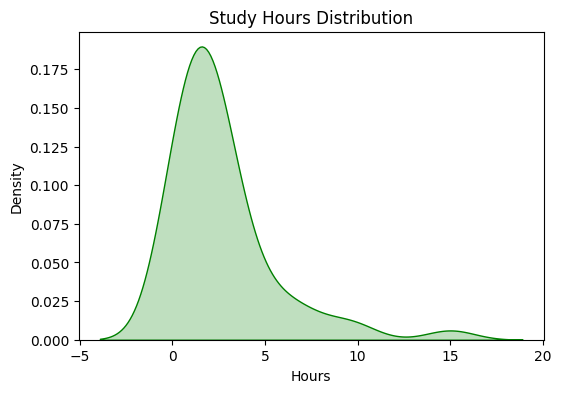

In [21]:
plt.figure(figsize=(6,4))
sns.kdeplot(df['study'], fill=True, color='green')
plt.title("Study Hours Distribution")
plt.xlabel("Hours")
plt.ylabel("Density")
plt.show()


# Instagram Usage KDE

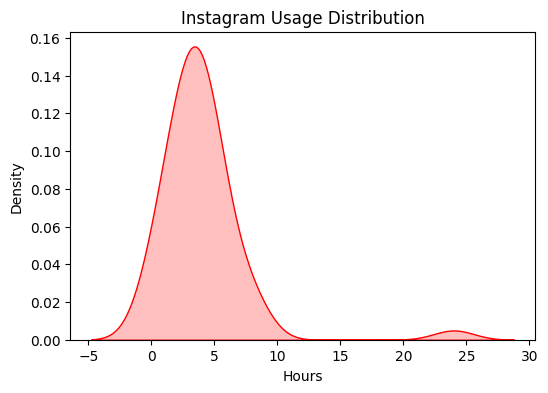

In [22]:
plt.figure(figsize=(6,4))
sns.kdeplot(df['instagram'], fill=True, color='red')
plt.title("Instagram Usage Distribution")
plt.xlabel("Hours")
plt.ylabel("Density")
plt.show()


# Sleep Hours KDE

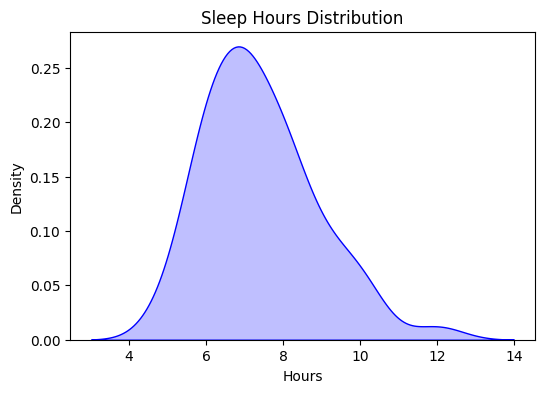

In [ ]:
plt.figure(figsize=(6,4))
sns.kdeplot(df['sleep'], fill=True, color='blue')
plt.title("Sleep Hours Distribution")
plt.xlabel("Hours")
plt.ylabel("Density")
plt.show()


# Comparison of all

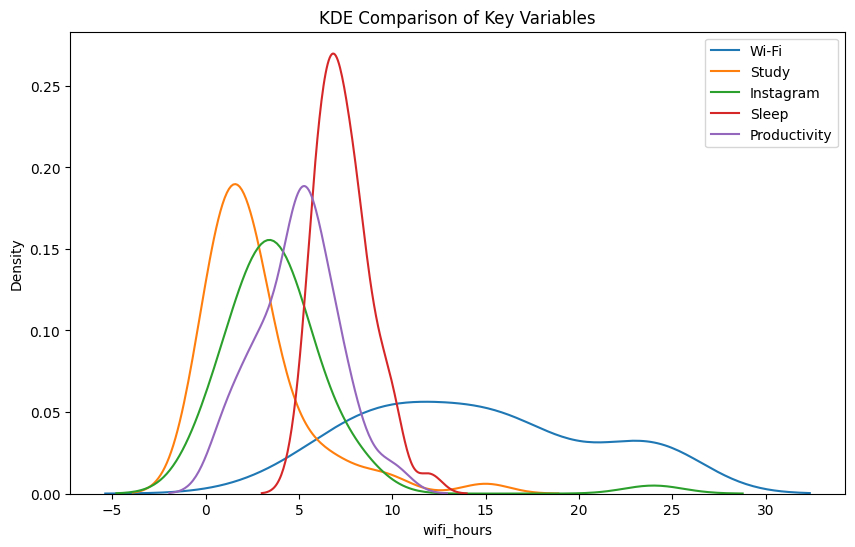

In [15]:
plt.figure(figsize=(10,6))

sns.kdeplot(df['wifi_hours'], label='Wi-Fi')
sns.kdeplot(df['study'], label='Study')
sns.kdeplot(df['instagram'], label='Instagram')
sns.kdeplot(df['sleep'], label='Sleep')
sns.kdeplot(df['productivity'], label='Productivity')

plt.title("KDE Comparison of Key Variables")
plt.legend()
plt.show()


# Outlier detection

# Study Hours Boxplot

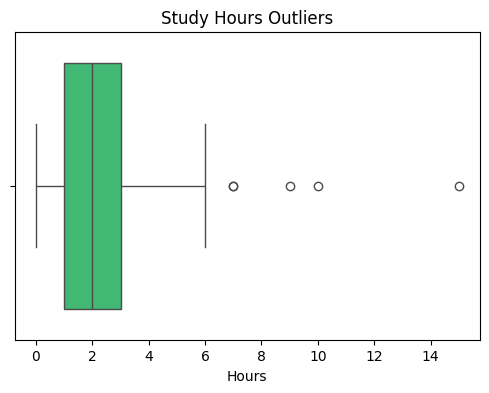

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['study'], color='#2ecc71')
plt.title("Study Hours Outliers")
plt.xlabel("Hours")
plt.show()


# Study Hours Boxplot

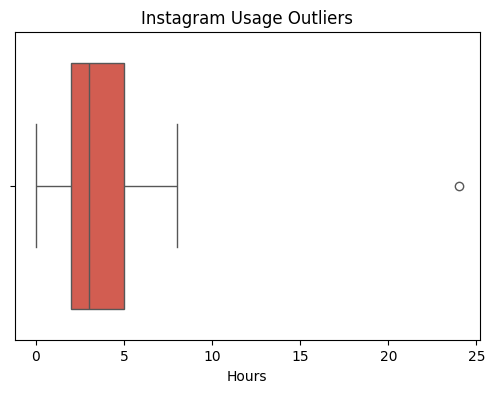

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['instagram'], color='#e74c3c')
plt.title("Instagram Usage Outliers")
plt.xlabel("Hours")
plt.show()


# Boxplot of All features

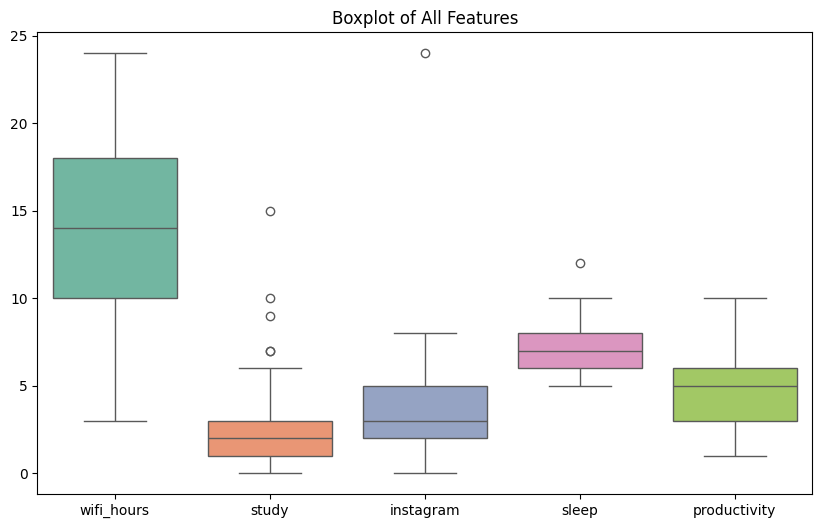

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df[['wifi_hours','study','instagram','sleep','productivity']],
    palette="Set2"
)
plt.title("Boxplot of All Features")
plt.show()


# Bivariate Relationships

# Regression plot

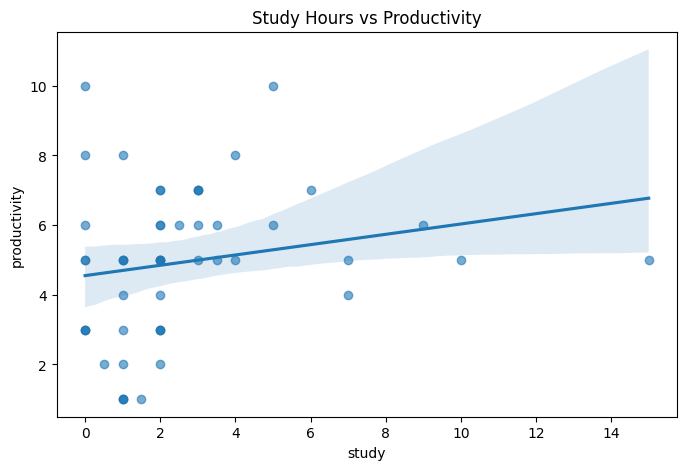

In [18]:
plt.figure(figsize=(8,5))
sns.regplot(x='study', y='productivity', data=df, scatter_kws={'alpha':0.6})
plt.title("Study Hours vs Productivity")
plt.show()


# Negative trend

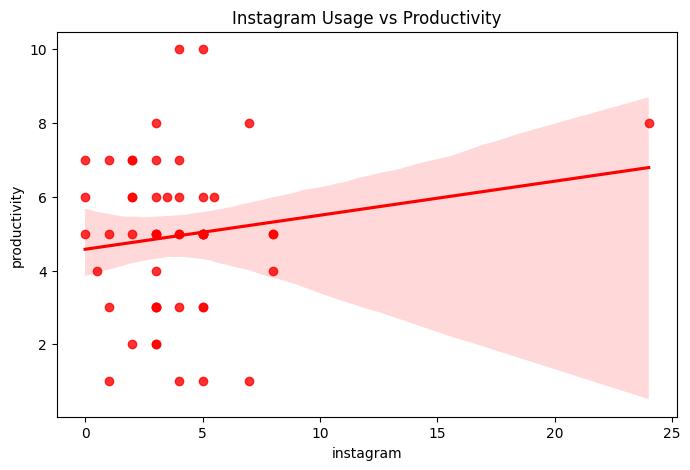

In [24]:
plt.figure(figsize=(8,5))
sns.regplot(x='instagram', y='productivity', data=df, color='red')
plt.title("Instagram Usage vs Productivity")
plt.show()


# Joint plot

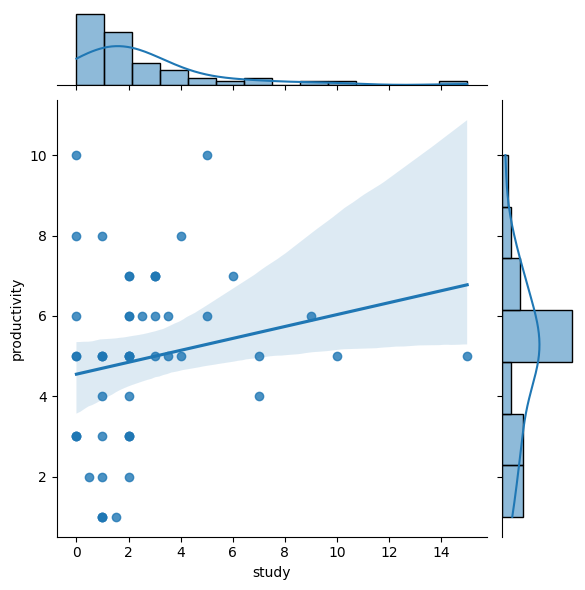

In [25]:
sns.jointplot(x='study', y='productivity', data=df, kind='reg')
plt.show()


# Multi-variable Analysis

#  Pairplot

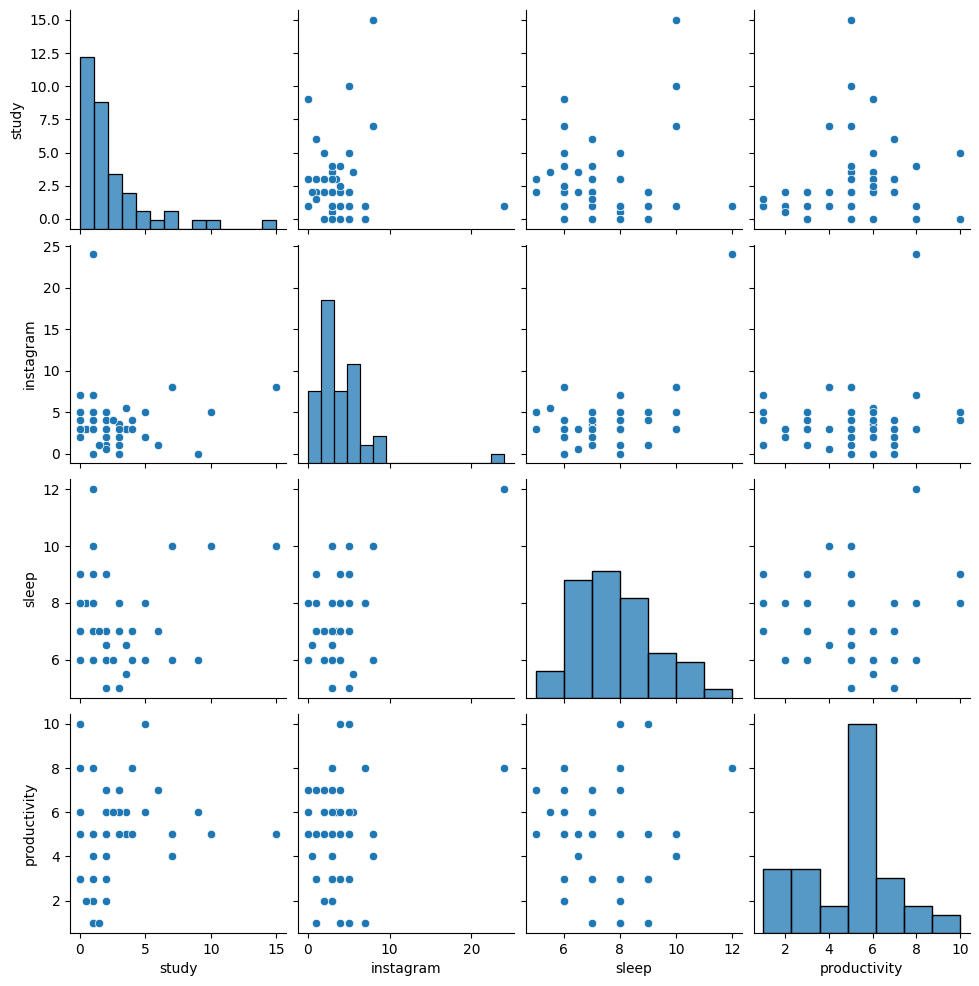

In [31]:
sns.pairplot(df[['study','instagram','sleep','productivity']])
plt.show()


# Correlation Analysis

# Heatmap

Numeric Columns:
 Index(['Age', 'wifi_hours', 'youtube', 'instagram', 'ott', 'edu', 'study',
       'productivity', 'sleep'],
      dtype='object')
Correlation Matrix:

                   Age  wifi_hours   youtube  instagram       ott       edu  \
Age           1.000000    0.242707 -0.019179   0.686901 -0.251045 -0.042054   
wifi_hours    0.242707    1.000000  0.322642   0.263593  0.351357  0.136082   
youtube      -0.019179    0.322642  1.000000  -0.059416  0.026159  0.265590   
instagram     0.686901    0.263593 -0.059416   1.000000  0.080075 -0.032157   
ott          -0.251045    0.351357  0.026159   0.080075  1.000000 -0.012237   
edu          -0.042054    0.136082  0.265590  -0.032157 -0.012237  1.000000   
study        -0.039617    0.124300  0.523260   0.063833 -0.036386  0.381929   
productivity  0.205988    0.421489  0.018880   0.150103  0.182111  0.112179   
sleep         0.446225    0.119899  0.188455   0.531882  0.171473 -0.029214   

                 study  productivity    

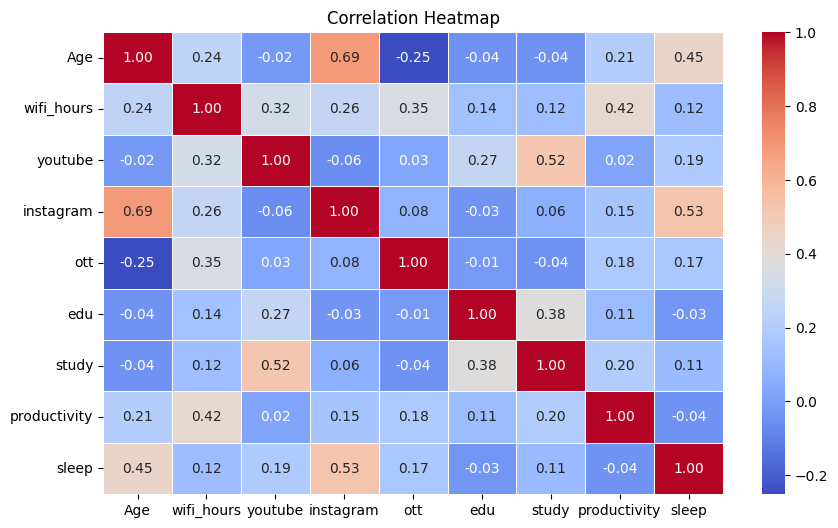

In [16]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Check columns used for correlation
print("Numeric Columns:\n", numeric_df.columns)

corr_matrix = numeric_df.corr()

# Show values
print("Correlation Matrix:\n")
print(corr_matrix)

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,          # show numbers
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",     # color theme
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()


# Correlation Bar Plot

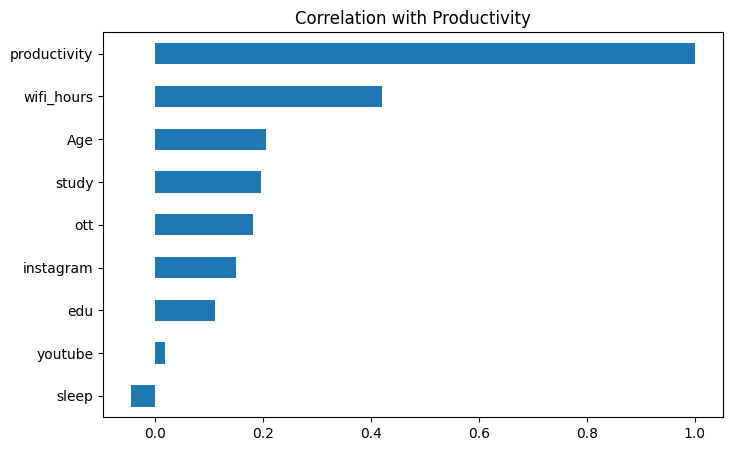

In [29]:
corr = df.select_dtypes(include='number').corr()['productivity'].sort_values()

corr.plot(kind='barh', figsize=(8,5))
plt.title("Correlation with Productivity")
plt.show()


# Categorical Analysis

# Sleep Category Analysis

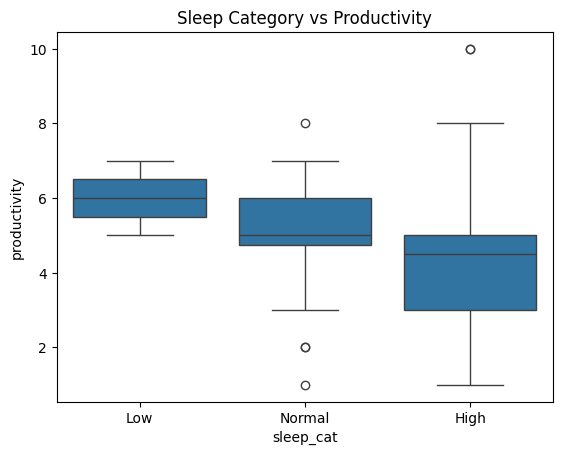

In [30]:
df['sleep_cat'] = pd.cut(df['sleep'], bins=[0,5,7,10], labels=['Low','Normal','High'])

sns.boxplot(x='sleep_cat', y='productivity', data=df)
plt.title("Sleep Category vs Productivity")
plt.show()


# Violin plot

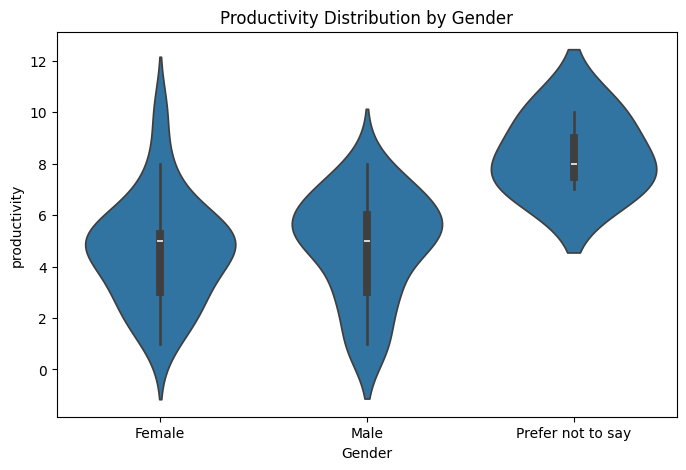

In [28]:
plt.figure(figsize=(8,5))
sns.violinplot(x='Gender', y='productivity', data=df)
plt.title("Productivity Distribution by Gender")
plt.show()


# 5. INTERACTIVE DASHBOARD

# 6. MODEL BUILDING

# Prepare Data

In [28]:
from sklearn.model_selection import train_test_split

X = df[['study', 'instagram', 'sleep', 'wifi_hours']]
y = df['productivity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Train Model

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Predictions

In [30]:
y_pred = model.predict(X_test)


# Evaluation

In [31]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)


MSE: 3.471298410551791
R2 Score: -0.41901049890799547


# Coefficients

In [32]:
coeff = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeff)


            Coefficient
study          0.097167
instagram      0.143505
sleep         -0.356047
wifi_hours     0.148172


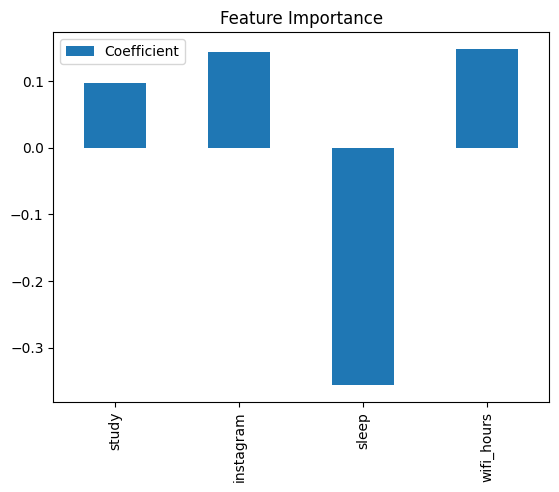

In [33]:
coeff.plot(kind='bar')
plt.title("Feature Importance")
plt.show()
